# STRATEGIA SU UNA SINGOLA COPPIA 

- [Cointegration](##Cointegrazione)
- [Parametri OU](##PARAMETRI-OU)
- [Spread e KF](##SPREAD-CON-KALMAN-FILTER)
- [Standardizzaziome](##STANDARDIZZAZIONE)
- [Hidden Markov Model](##HIDDEN-MARKOV-MODEL)
- [Trading Signals](##SEGNALI-TRADING)
- [Backtest](##BACKTEST)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.stats import norm, skew, kurtosis
from pykalman import KalmanFilter
from hmmlearn.hmm import GaussianHMM

In [9]:
tickers = ['MA', 'V' ]  # Mastercard e VISA

data = yf.download(tickers, start="2021-01-01", end="2026-01-01", progress=False, auto_adjust=False)['Adj Close'] 

df = pd.DataFrame(data)
#df.to_csv("MA_V_2020-2025.csv")

df.shape

/opt/anaconda3/lib/python3.11/site-packages/yfinance/scrapers/history.py:173: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


(1255, 2)

In [10]:
#df = pd.read_csv("./MA_V_2020-2025.csv", parse_dates=["Date"], index_col="Date")
df.head(10)

Ticker,MA,V
Date,,
2021-01-04,341.164642,209.572952
2021-01-05,337.214264,206.445129
2021-01-06,337.340393,204.626205
2021-01-07,340.013062,205.771454
2021-01-08,343.890747,207.349823
2021-01-11,338.399719,204.886032
2021-01-12,333.268372,201.007553
2021-01-13,336.582275,201.479141
2021-01-14,317.728363,194.270737


In [11]:
df.corr()

Ticker,MA,V
Ticker,,
MA,1.000000,0.987371
V,0.987371,1.000000


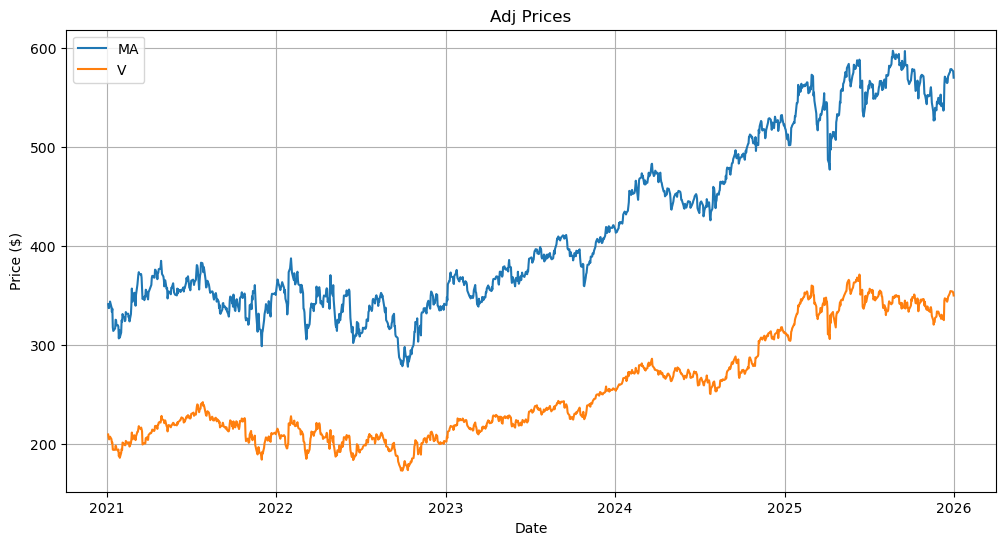

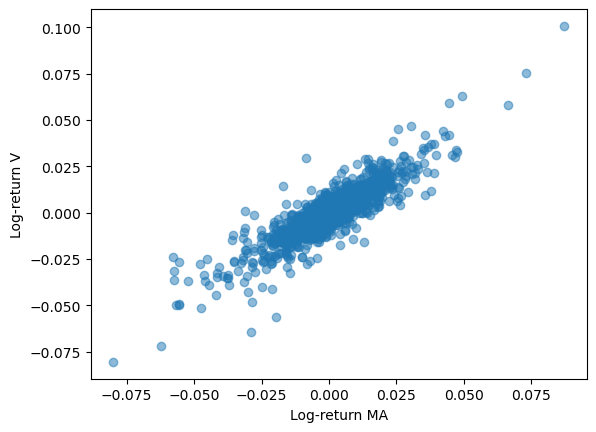

In [12]:
plt.figure(figsize=(12, 6))
for ticker in tickers:
    plt.plot(data.index, data[ticker], label=ticker)

plt.title("Adj Prices")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid()
plt.show()

df["ret_MA"] = np.log(df["MA"] / df["MA"].shift(1))
df["ret_V"] = np.log(df["V"] / df["V"].shift(1))


plt.figure()
plt.scatter(df["ret_MA"], df["ret_V"], alpha=0.5)
plt.xlabel("Log-return MA")
plt.ylabel("Log-return V")
plt.show()

df.drop(columns=["ret_MA", "ret_V"], inplace=True)

## Spread con Kalman Filter


In [13]:
'''Kalman Filter'''

# Stima Q e R (EM Algorithm)
def stima_QR_EM(df_train, em_iter=50):
    y = df_train.iloc[:, 0].values.reshape(-1, 1)
    x = df_train.iloc[:, 1].values
    n_obs = len(df_train)

    A = np.eye(2)
    H = np.zeros((n_obs, 1, 2))
    H[:, 0, 0] = 1.0
    H[:, 0, 1] = x

    kf = KalmanFilter(      # kf.em() 
        transition_matrices=A,
        observation_matrices=H,
        initial_state_mean=[0.0, 1.0],
        initial_state_covariance=np.eye(2) * 100
    ).em(y, n_iter=em_iter, em_vars=['transition_covariance', 'observation_covariance'])

    Q_hat = kf.transition_covariance.copy()
    R_hat = kf.observation_covariance.copy()
    return Q_hat, R_hat # --> controllare se converge!

N_train = 315
Q_hat, R_hat = stima_QR_EM(df.iloc[:N_train])




def kalman_spread(df, Q, R):        
    n_obs = len(df)
    y_vals = df.iloc[:,0].values
    x_vals = df.iloc[:,1].values 

    A = np.eye(2)                                    # Transition Matrix  

    # Observation matrices pre-computate
    observation_matrices = np.zeros((n_obs, 1, 2))
    observation_matrices[:, 0, 0] = 1.0
    observation_matrices[:, 0, 1] = x_vals

    kf = KalmanFilter(
        transition_matrices=A,
        observation_matrices=observation_matrices,  
        initial_state_mean=[0.0, 1.0],
        initial_state_covariance=np.eye(2) * 100,     # 100*I --> grande libertà ai parametri all'inizio
        transition_covariance = Q,                    # rumore di processo
        observation_covariance = R                    # rumore di osservazione
    )

    state_means, _ = kf.filter(y_vals.reshape(-1, 1))  # non usare smooth!
    alpha_t = state_means[:, 0]
    beta_t  = state_means[:, 1]
    spread  = y_vals - (alpha_t + beta_t * x_vals)
    return alpha_t, beta_t, spread




alpha_t, beta_t, spread_kf = kalman_spread(df, Q=Q_hat, R=R_hat)
df['alpha_t']   = alpha_t
df['beta_t']    = beta_t
df['spread_kf'] = spread_kf

In [14]:
print("Q: ", Q_hat)
print("R: ", R_hat)

Q:  [[ 1.07370524e+00 -1.25655794e-04]
 [-1.25655794e-04  1.54223445e-04]]
R:  [[0.85322231]]


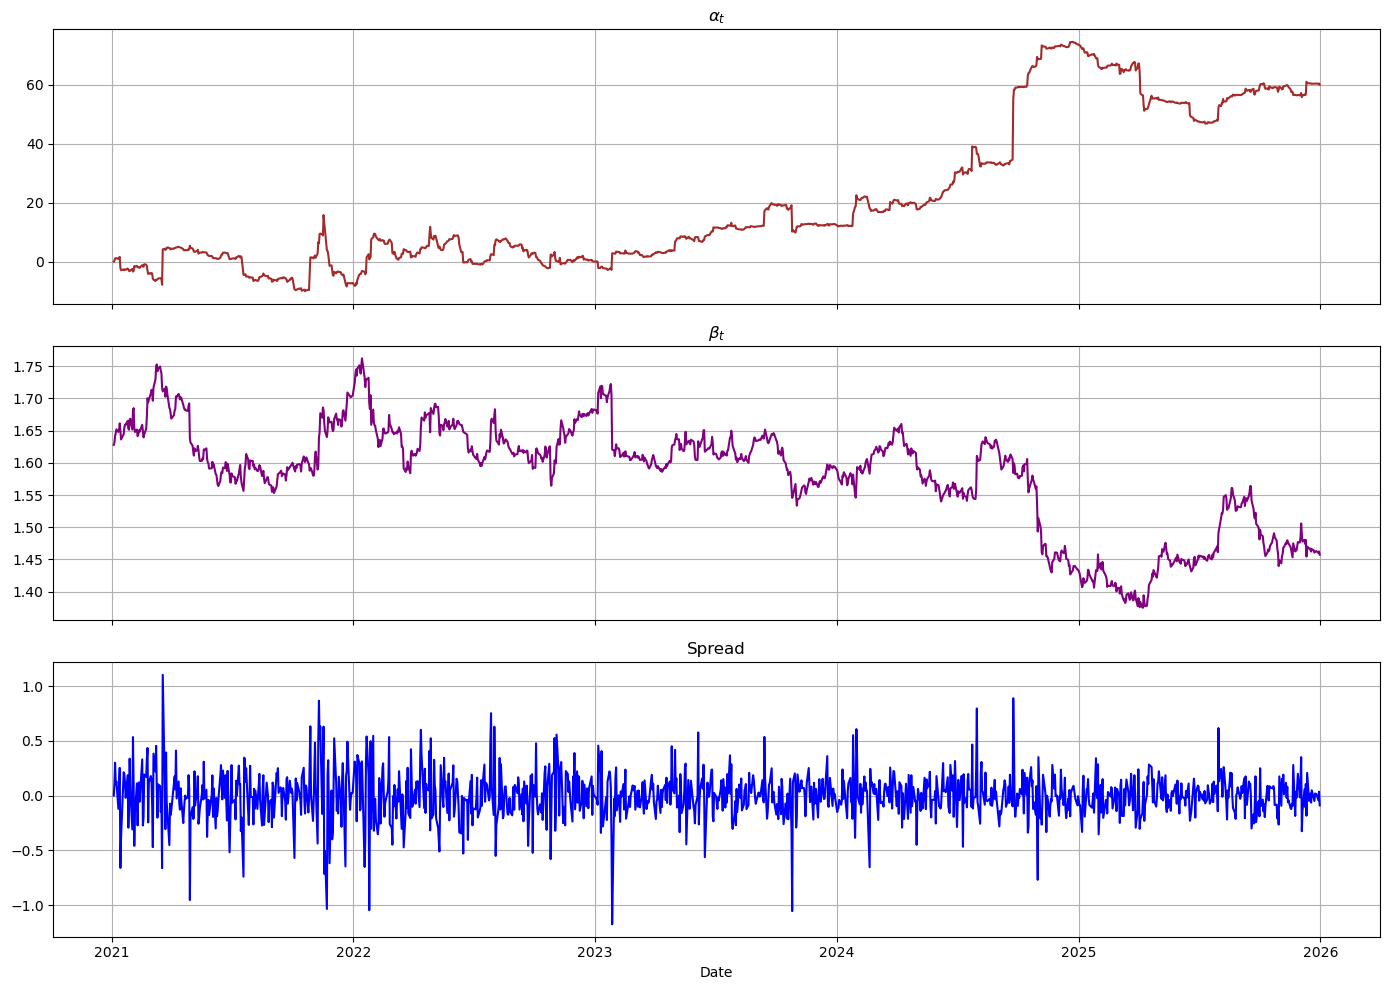

In [15]:
fig, ax = plt.subplots(3, 1, figsize=(14,10), sharex=True)

# Alfa_t
ax[0].plot(df.index, df['alpha_t'], color='brown')
ax[0].set_title(r"$\alpha_t$")
ax[0].grid(True)

# Beta_t
ax[1].plot(df.index, df['beta_t'], color='purple')
ax[1].set_title(r"$\beta_t$")
ax[1].grid(True)

# Spread
ax[2].plot(df.index, df['spread_kf'], color='blue')
ax[2].set_title("Spread")
ax[2].set_xlabel("Date")
ax[2].grid(True)

plt.tight_layout()
plt.show()

In [16]:
df.head()

Ticker,MA,V,alpha_t,beta_t,spread_kf
Date,,,,,
2021-01-04,341.164642,209.572952,0.002996,1.627890,0.000026
2021-01-05,337.214264,206.445129,0.314820,1.631401,0.104737
2021-01-06,337.340393,204.626205,1.074645,1.641853,0.299663
2021-01-07,340.013062,205.771454,1.156266,1.646270,0.101404
2021-01-08,343.890747,207.349823,1.205251,1.652081,0.126717


## Parametri OU

In [18]:
# Parametri Ornstein-Uhlenbeck
def estimate_ou_params(spread_kf, dt=1.0, kappa_floor=1e-3):
    x = spread_kf.values
    y = x[1:]
    x0 = x[:-1]

    # Regressione OLS discreta
    b, a = np.polyfit(x0, y, 1)
    if not (0 < b < 1):  # Verifica mean-reversion: 0 < b < 1
        return np.nan, np.nan, np.nan, np.nan

    # kappa e mu
    kappa = -np.log(b) / dt
    kappa = max(kappa, kappa_floor)
    mu    = a / (1 - b)

    # Varianza dei residui
    resid  = y - (b * x0 + a)
    omega2 = np.var(resid, ddof=1)

    # Sigma stazionario
    try:
        sigma = np.sqrt(2 * kappa * omega2 / (1 - np.exp(-2 * kappa * dt)))
    except (ValueError, ZeroDivisionError):
        return np.nan, np.nan, np.nan, np.nan

    # Half-life
    half_life = np.log(2) / kappa

    return kappa, mu, sigma, half_life

kappa, mu, sigma, half_life = estimate_ou_params(pd.Series(spread_kf))

print("kappa:     ", kappa.round(3))
print("mu:        ", mu.round(3))
print("sigma:     ", sigma.round(3))
print("half-life: ", half_life.round(3))

kappa:      3.014
mu:         0.001
sigma:      0.52
half-life:  0.23


## Standardizzazione

In [19]:
window_size = 60 

spread_kf = df['spread_kf']
rm = spread_kf.rolling(window_size, min_periods=1).mean().shift(1)
rs = spread_kf.rolling(window_size, min_periods=1).std().shift(1)
zscore_kf = (spread_kf - rm) / rs
zscore_kf = zscore_kf.replace([np.inf, -np.inf], 0).fillna(0)


df['rolling_mean'] = rm
df['rolling_std'] = rs
df['z_kf'] = zscore_kf

df.head()

Ticker,MA,V,alpha_t,beta_t,spread_kf,rolling_mean,rolling_std,z_kf
Date,,,,,,,,
2021-01-04,341.164642,209.572952,0.002996,1.627890,0.000026,NaN,NaN,0.000000
2021-01-05,337.214264,206.445129,0.314820,1.631401,0.104737,0.000026,NaN,0.000000
2021-01-06,337.340393,204.626205,1.074645,1.641853,0.299663,0.052381,0.074042,3.339740
2021-01-07,340.013062,205.771454,1.156266,1.646270,0.101404,0.134808,0.152065,-0.219669
2021-01-08,343.890747,207.349823,1.205251,1.652081,0.126717,0.126457,0.125279,0.002074


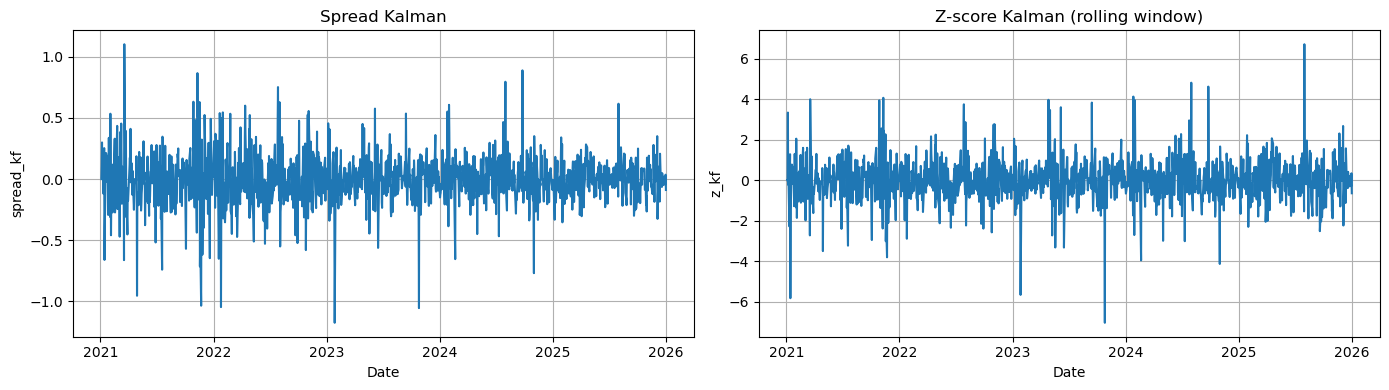

In [20]:
columns = ['spread_kf', 'z_kf']
titles  = ['Spread Kalman', 'Z-score Kalman (rolling window)']

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 4), sharex=True)

axes = axes.flatten()

for ax, col, title in zip(axes, columns, titles):
    ax.plot(df[col])
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.set_ylabel(col)
    ax.grid(True)

plt.tight_layout()
plt.show()

In [21]:
df.head()

Ticker,MA,V,alpha_t,beta_t,spread_kf,rolling_mean,rolling_std,z_kf
Date,,,,,,,,
2021-01-04,341.164642,209.572952,0.002996,1.627890,0.000026,NaN,NaN,0.000000
2021-01-05,337.214264,206.445129,0.314820,1.631401,0.104737,0.000026,NaN,0.000000
2021-01-06,337.340393,204.626205,1.074645,1.641853,0.299663,0.052381,0.074042,3.339740
2021-01-07,340.013062,205.771454,1.156266,1.646270,0.101404,0.134808,0.152065,-0.219669
2021-01-08,343.890747,207.349823,1.205251,1.652081,0.126717,0.126457,0.125279,0.002074


## Scelta entry - exit

In [22]:
def simulate_ou_paths(n_paths, n_steps, kappa, mu, sigma, dt=1.0, x0=0.0, seed=42):
    rng = np.random.default_rng(seed)
    
    phi = np.exp(-kappa * dt)
    s2 = (sigma**2) * (1 - np.exp(-2*kappa*dt)) / (2*kappa)
    s = np.sqrt(s2)
    
    X = np.empty((n_paths, n_steps), dtype=np.float32)
    X[:, 0] = x0
    
    eps = rng.standard_normal((n_paths, n_steps-1), dtype=np.float32)
    for t in range(1, n_steps):
        X[:, t] = mu + (X[:, t-1] - mu) * phi + s * eps[:, t-1]
    return X

def backtest_thresholds_paths(X, entry, exit_, cost_per_turn=0.0):
    """
    X: (n_paths, n_steps) OU paths (z/spread)
    entry, exit_: soglie positive (exit_ < entry tipicamente)
    """
    n_paths, n_steps = X.shape
    pos = np.zeros(n_paths, dtype=np.int8)
    pnl = np.zeros((n_paths, n_steps-1), dtype=np.float32)
    
    for t in range(1, n_steps):
        z = X[:, t]
        z_prev = X[:, t-1]
        dz = z - z_prev
        
        # segnali di ingresso (solo se flat)
        enter_short = (pos == 0) & (z >= entry)
        enter_long  = (pos == 0) & (z <= -entry)
        
        # segnali di uscita (solo se in posizione)
        exit_pos = (pos != 0) & (np.abs(z) < exit_)
        
        # PnL usa posizione PRECEDENTE
        pnl[:, t-1] = pos.astype(np.float32) * dz
        
        # costi su cambi posizione (entry o exit)
        if cost_per_turn > 0.0:
            # cambi in questo step: entry o exit
            n_trades = enter_short.astype(np.int8) + enter_long.astype(np.int8) + exit_pos.astype(np.int8)
            pnl[:, t-1] -= cost_per_turn * n_trades
        
        # aggiorna posizione
        pos = np.where(exit_pos, 0, pos)
        pos = np.where(enter_short, -1, pos)
        pos = np.where(enter_long,  +1, pos)
    
    # metriche per path
    total_pnl = pnl.sum(axis=1)
    mean_pnl_step = pnl.mean(axis=1)
    std_pnl_step = pnl.std(axis=1, ddof=1)
    sharpe = np.where(std_pnl_step > 0, mean_pnl_step / std_pnl_step * np.sqrt(252), 0.0)  # annualizzazione opzionale
    
    return {
        "total_pnl": total_pnl,
        "sharpe": sharpe
    }

def grid_search_thresholds(X, entry_grid, exit_grid, cost_per_turn=0.0):
    results = []
    for entry in entry_grid:
        for exit_ in exit_grid:
            if exit_ >= entry:
                continue
            
            out = backtest_thresholds_paths(X, entry, exit_, cost_per_turn=cost_per_turn)
            total_pnl = out["total_pnl"]
            sharpe = out["sharpe"]
            
            res = {
                "entry": entry,
                "exit": exit_,
                "mean_total_pnl": float(np.mean(total_pnl)),
                "median_total_pnl": float(np.median(total_pnl)),
                "p_total_pnl_pos": float(np.mean(total_pnl > 0)),
                "mean_sharpe": float(np.mean(sharpe)),
                "median_sharpe": float(np.median(sharpe)),
                "p_sharpe_pos": float(np.mean(sharpe > 0)),
                "sharpe_p10": float(np.quantile(sharpe, 0.10)),
                "sharpe_p90": float(np.quantile(sharpe, 0.90)),
            }
            results.append(res)
    
    # ordina per sharpe medio (puoi cambiare criterio)
    results.sort(key=lambda d: d["mean_sharpe"], reverse=True)
    return results

kappa = 1.904
mu    = 0.002
sigma = 1.220

n_paths = 20000
n_steps = len(df)
dt = 1.0
x0 = 0.0

X = simulate_ou_paths(
    n_paths=n_paths,
    n_steps=n_steps,
    kappa=kappa,
    mu=mu,
    sigma=sigma,
    dt=dt,
    x0=x0,
    seed=123
)

entry_grid = np.array([0.3, 0.5, 0.6, 0.7, 1.0, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8])
exit_grid = np.array([0.3, 0.5, 0.6, 0.7, 1.0, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8])
cost_per_turn = 0.0                    

results = grid_search_thresholds(X, entry_grid, exit_grid, cost_per_turn=cost_per_turn)

# top 3
results[:3]

/var/folders/3s/gk3lt8991f7_369kj0_7nn3r0000gn/T/ipykernel_77238/2373304725.py:55: RuntimeWarning: invalid value encountered in divide
  sharpe = np.where(std_pnl_step > 0, mean_pnl_step / std_pnl_step * np.sqrt(252), 0.0)  # annualizzazione opzionale


[{'entry': 0.7,
  'exit': 0.6,
  'mean_total_pnl': 227.9011993408203,
  'median_total_pnl': 227.82272338867188,
  'p_total_pnl_pos': 1.0,
  'mean_sharpe': 5.356954574584961,
  'median_sharpe': 5.356063365936279,
  'p_sharpe_pos': 1.0,
  'sharpe_p10': 5.017857789993286,
  'sharpe_p90': 5.700839900970459},
 {'entry': 0.6,
  'exit': 0.5,
  'mean_total_pnl': 240.1236572265625,
  'median_total_pnl': 239.93313598632812,
  'p_total_pnl_pos': 1.0,
  'mean_sharpe': 5.198150634765625,
  'median_sharpe': 5.195158958435059,
  'p_sharpe_pos': 1.0,
  'sharpe_p10': 4.8674681186676025,
  'sharpe_p90': 5.531804752349854},
 {'entry': 0.7,
  'exit': 0.5,
  'mean_total_pnl': 221.0187530517578,
  'median_total_pnl': 220.8725128173828,
  'p_total_pnl_pos': 1.0,
  'mean_sharpe': 5.0279541015625,
  'median_sharpe': 5.024580001831055,
  'p_sharpe_pos': 1.0,
  'sharpe_p10': 4.701306962966919,
  'sharpe_p90': 5.362040853500366}]

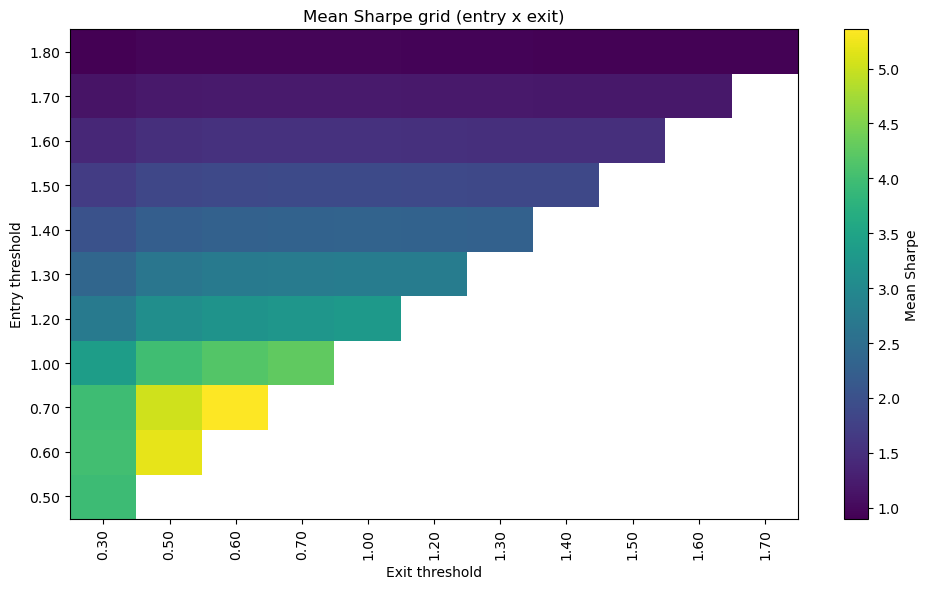

In [23]:
res_df = pd.DataFrame(results)

# griglia: righe=entry, colonne=exit, valori=mean_sharpe
sharpe_grid = res_df.pivot(index="entry", columns="exit", values="mean_sharpe")

# ordina per avere entry crescente e exit crescente
sharpe_grid = sharpe_grid.sort_index().sort_index(axis=1)


fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(sharpe_grid.values, aspect="auto", origin="lower")

ax.set_xticks(np.arange(sharpe_grid.shape[1]))
ax.set_xticklabels([f"{c:.2f}" for c in sharpe_grid.columns], rotation=90)

ax.set_yticks(np.arange(sharpe_grid.shape[0]))
ax.set_yticklabels([f"{i:.2f}" for i in sharpe_grid.index])

ax.set_xlabel("Exit threshold")
ax.set_ylabel("Entry threshold")
ax.set_title("Mean Sharpe grid (entry x exit)")

fig.colorbar(im, ax=ax, label="Mean Sharpe")
plt.tight_layout()
plt.show()

## Hidden Markov Model

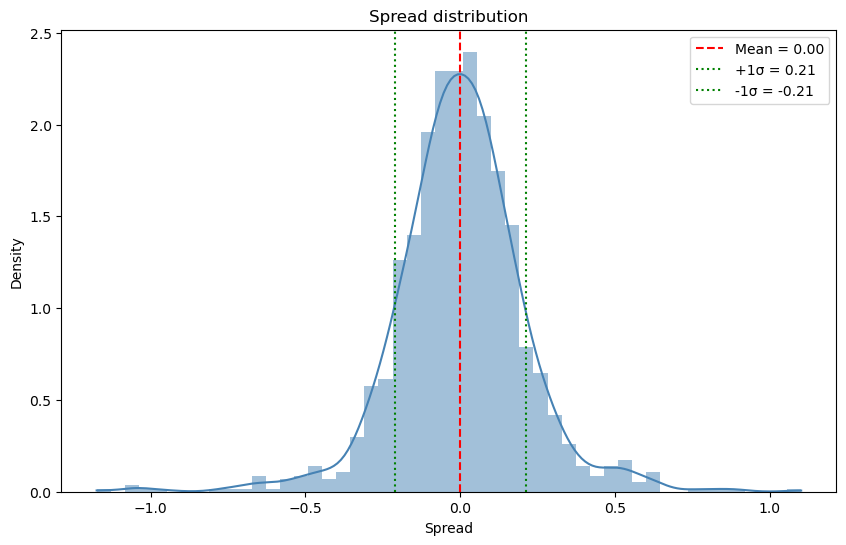

In [24]:
# distribuzione spread (verificare normalità)

def plot_spread_distribution(spread, bins=50):
    spread = np.asarray(spread)
    spread = spread[~np.isnan(spread)]  # rimuovi eventuali NaN
    
    plt.figure(figsize=(10,6))
    
    # Istogramma + kde
    sns.histplot(spread, bins=bins, kde=True, stat="density", color="steelblue", edgecolor=None)
    
    # Aggiungo media e ±1σ
    mu = np.mean(spread)
    sigma = np.std(spread)
    plt.axvline(mu, color="red", linestyle="--", label=f"Mean = {mu:.2f}")
    plt.axvline(mu+sigma, color="green", linestyle=":", label=f"+1σ = {mu+sigma:.2f}")
    plt.axvline(mu-sigma, color="green", linestyle=":", label=f"-1σ = {mu-sigma:.2f}")
    
    plt.title("Spread distribution")
    plt.xlabel("Spread")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

plot_spread_distribution(spread_kf)

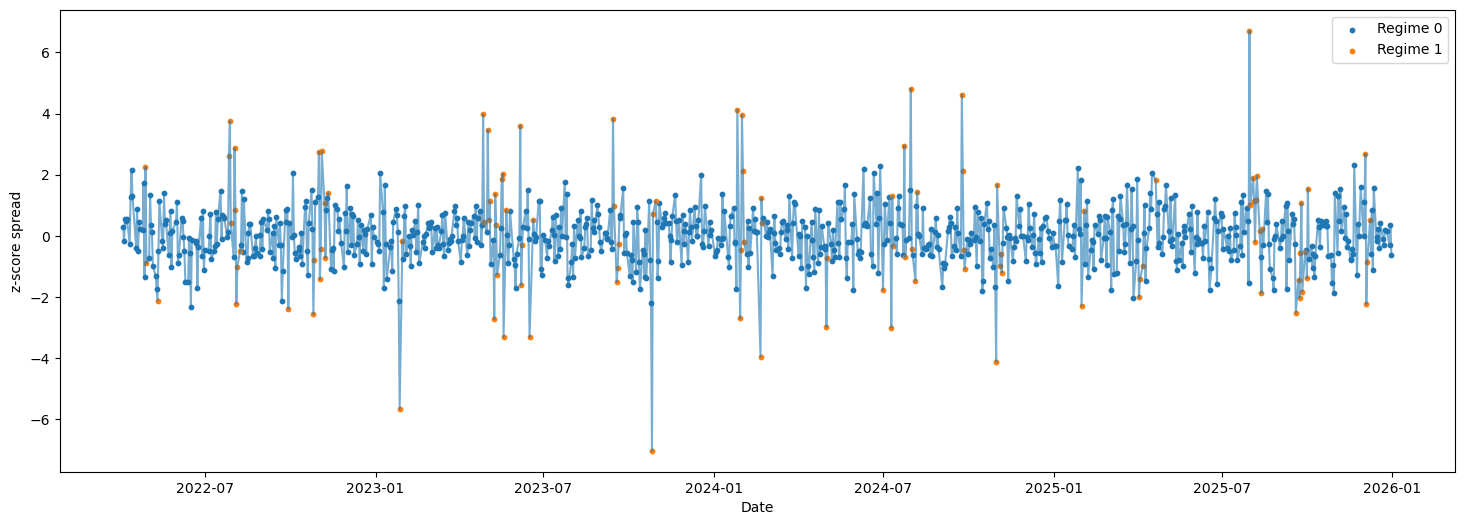

In [25]:
# addestramento modello

window = 315
zs = df['z_kf'].values.reshape(-1, 1)   # (T, 1)
n = len(zs)

model = GaussianHMM(
    n_components=2,
    covariance_type='diag',
    n_iter=200,
    tol=1e-4,    
    init_params="stmc"
)
model.fit(zs[:window])

state_vars = model.covars_.reshape(model.n_components, -1).sum(axis=1)
hi_var_state = int(np.argmax(state_vars))
def remap(state_arr):
    # 1 = high variance, 0 = low variance
    return np.where(state_arr == hi_var_state, 1, 0)

regimes = np.empty(n - window, dtype=int)

for i in range(n - window):
    # Sequenza fino a "oggi" (o usa una finestra scorrevole)
    seq = zs[i : i + window + 1]          # NO look-ahead
    states = model.predict(seq)           # Viterbi sulla sequenza
    regimes[i] = remap(states)[-1]        # ultimo stato = stato di "oggi"

df = df.iloc[window:].copy()
df['regime'] = regimes


plt.figure(figsize=(18, 6))
plt.plot(df.index, df['z_kf'], alpha=0.6)
for state in [0, 1]:
    mask = df['regime'] == state
    plt.scatter(
        df.index[mask],
        df['z_kf'][mask],
        s=10,
        label=f'Regime {state}'
    )
plt.xlabel('Date')
plt.ylabel('z-score spread')
plt.legend()
plt.show()

=== HMM Gaussian emissions (mapped to regime 0/1) ===
Regime 0 (Low-variance): mu = 0.0126, sigma = 0.7705
Regime 1 (High-variance): mu = -0.0734, sigma = 2.0265
Empirical regime 0: variance = 0.6197, std = 0.7872
Empirical regime 1: variance = 5.1697, std = 2.2737


/var/folders/3s/gk3lt8991f7_369kj0_7nn3r0000gn/T/ipykernel_77238/182017805.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


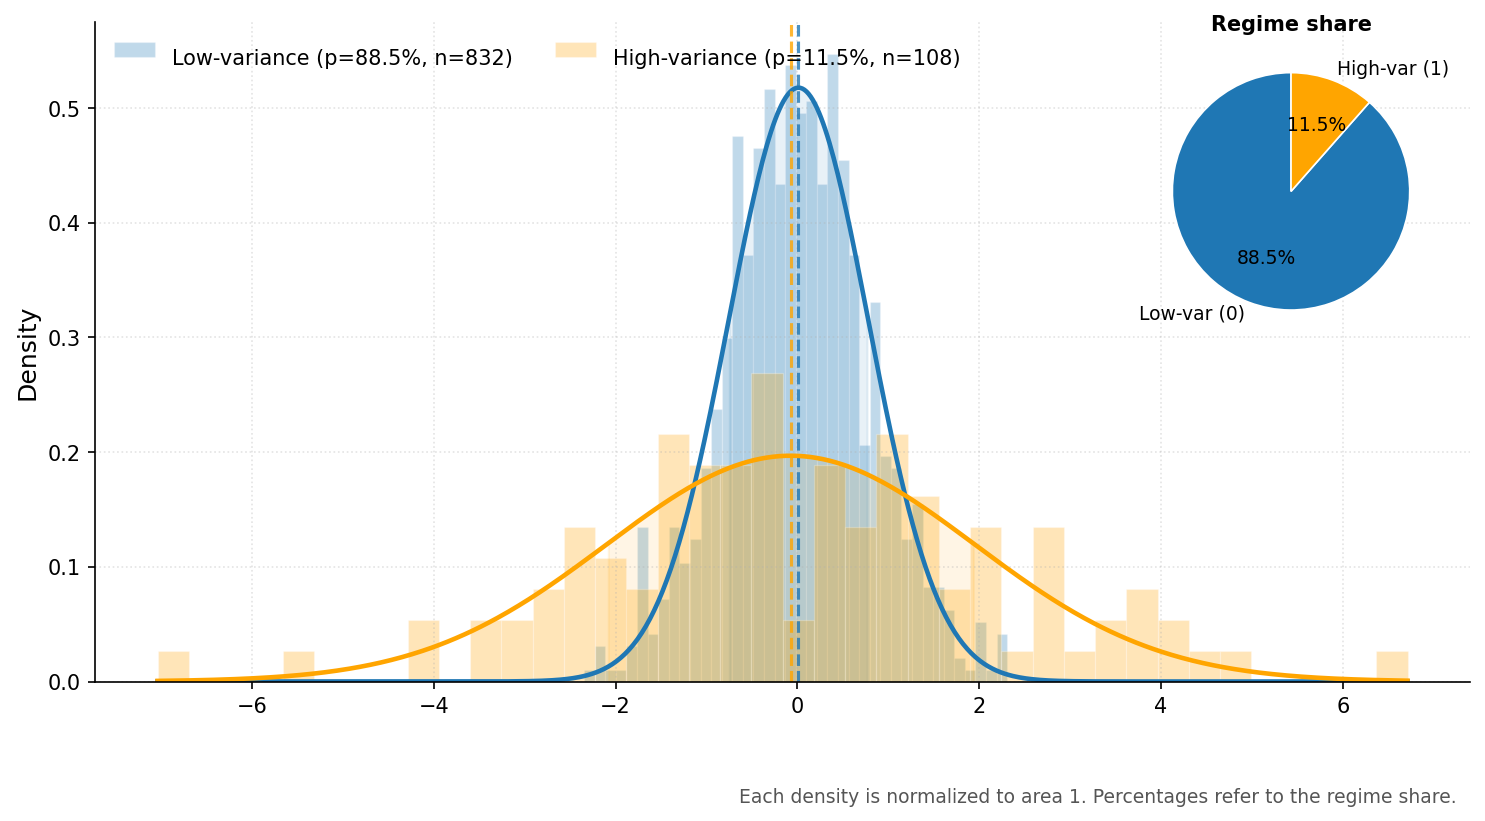

In [26]:
def plotHMM(df, model, feature_name='z_kf'):

    means_raw = np.asarray(model.means_).squeeze()         
    cov = np.asarray(model.covars_)
    cov = np.squeeze(cov)                                  
    if cov.ndim == 1:
        stds_raw = np.sqrt(cov)                          
    elif cov.ndim == 2:
        stds_raw = np.sqrt(cov[:, 0])
    else:
        stds_raw = np.sqrt(cov[:, 0, 0])


    low_var_state_model  = int(np.argmin(stds_raw))
    high_var_state_model = int(np.argmax(stds_raw))

    mu_map  = {0: float(means_raw[low_var_state_model]),  1: float(means_raw[high_var_state_model])}
    std_map = {0: float(stds_raw[low_var_state_model]),   1: float(stds_raw[high_var_state_model])}

    print("=== HMM Gaussian emissions (mapped to regime 0/1) ===")
    for s in (0, 1):
        lab = "Low-variance" if s == 0 else "High-variance"
        print(f"Regime {s} ({lab}): mu = {mu_map[s]:.4f}, sigma = {std_map[s]:.4f}")


    variances = df.groupby('regime')[feature_name].var()
    stds_emp  = df.groupby('regime')[feature_name].std()
    for state in variances.index:
        print(f"Empirical regime {state}: variance = {variances[state]:.4f}, std = {stds_emp[state]:.4f}")

    counts = df['regime'].value_counts().sort_index()
    pcts   = (counts / counts.sum() * 100).round(1)

    # plot
    plt.rcParams.update({
        "figure.dpi": 150, "axes.spines.top": False, "axes.spines.right": False,
        "axes.titleweight": "bold", "axes.grid": True, "grid.alpha": 0.35, "grid.linestyle": ":",
    })
    fig, ax = plt.subplots(figsize=(10, 5.5))
    colors = {0: "#1f77b4", 1: "orange"}

    x = np.linspace(df[feature_name].min(), df[feature_name].max(), 600)

    for s in (0, 1):
        data = df.loc[df['regime'] == s, feature_name].to_numpy()
        label = f'{"Low" if s==0 else "High"}-variance (p={pcts.get(s,0):.1f}%, n={int(counts.get(s,0))})'
        ax.hist(data, bins=40, density=True, alpha=0.28, label=label,
                color=colors[s], edgecolor="white", linewidth=0.6)

        m, sg = mu_map[s], std_map[s]
        pdf = (1.0 / (sg * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - m) / sg) ** 2)
        ax.plot(x, pdf, color=colors[s], linewidth=2.2)
        ax.axvline(m, color=colors[s], linestyle="--", linewidth=1.5, alpha=0.8)
        ax.fill_between(x, 0, pdf, where=(x >= m - sg) & (x <= m + sg),
                        color=colors[s], alpha=0.10)

    #ax.set_title("HMM Estimated State Distributions", fontsize=15)
    ax.set_ylabel("Density", fontsize=12)
    ax.text(0.99, -0.16,
            "Each density is normalized to area 1. Percentages refer to the regime share.",
            transform=ax.transAxes, ha="right", va="top", fontsize=9, color="#555")

    leg = ax.legend(frameon=False, fontsize=10, ncol=2, loc="upper left")
    for t in leg.get_texts():
        t.set_va("center_baseline")

    axins = inset_axes(ax, width="23%", height="45%", loc="upper right", borderpad=1.0)
    axins.set_title("Regime share", fontsize=10, pad=6)
    axins.pie([counts.get(0, 0), counts.get(1, 0)],
              labels=["Low-var (0)", "High-var (1)"],
              autopct="%1.1f%%", startangle=90,
              colors=[colors[0], colors[1]],
              wedgeprops={"edgecolor": "white", "linewidth": 0.8},
              textprops={"fontsize": 9})

    plt.tight_layout(); plt.show()


plotHMM(df, model)

In [27]:
# Matrice di transizione 2×2, calcolata all'ultimo step del loop
A = model.transmat_

print(A)

[[0.95959039 0.04040961]
 [0.18455015 0.81544985]]


## Segnali Trading


-    0 = close
-    1 = long  (buy MA, sell V)
-    -1 = short (sell MA, buy V)

In [28]:
def generate_signals(df, entry_thresh, exit_thresh, HMM=True):
    sig = np.zeros(len(df), dtype=int)
    position = 0

    for i in range(len(df)):
        z = df.loc[df.index[i], 'z_kf']
        regime = df.loc[df.index[i], 'regime']
        
        if HMM: # ACCESO
            if regime == 1: 
                position = 0           
            else:
                if position == 0:
                    # se non ho posizione, cerco quando entrare
                    if z >= entry_thresh:
                        position = -1  # spread alto → short 
                    elif z <= -entry_thresh:
                        position = 1   # spread basso → long 
                else:
                    # se ho già posizione, cerco quando uscire
                    if abs(z) < exit_thresh:
                        position = 0   # zscore ha ritracciato → chiudo
        else:   # SPENTO
                if position == 0:
                    if z >= entry_thresh:
                        position = -1  
                    elif z <= -entry_thresh:
                        position = 1   
                else:
                    if abs(z) < exit_thresh:
                        position = 0   
                    
        sig[i] = position

    return sig

### SEGNALI

In [29]:
# best params from SC simulation
entry_t = 0.7
exit_t = 0.6

df['signal'] = generate_signals(df, entry_thresh=entry_t, exit_thresh=exit_t, HMM=True) # !!!
df['position'] = df['signal'].shift(1).fillna(0)  # la posizione entra/esce il giorno dopo 

In [30]:
df.tail(10)

Ticker,MA,V,alpha_t,beta_t,spread_kf,rolling_mean,rolling_std,z_kf,regime,signal,position
Date,,,,,,,,,,,
2025-12-17,564.621887,343.701263,60.438213,1.466870,0.018488,-0.014043,0.144117,0.225727,0,0,0.0
2025-12-18,565.360779,345.297974,60.470774,1.462372,-0.064204,-0.009503,0.140682,-0.388827,0,0,0.0
2025-12-19,571.371704,348.531281,60.351600,1.466071,0.048495,-0.009601,0.140719,0.412853,0,0,0.0
2025-12-22,574.836548,351.365448,60.403612,1.464168,-0.025193,-0.011723,0.138823,-0.097025,0,0,0.0
2025-12-23,575.485535,352.652802,60.418797,1.460689,-0.049248,-0.008119,0.135524,-0.303481,0,0,0.0
2025-12-24,578.580933,354.409180,60.404647,1.462032,0.018601,-0.007947,0.135465,0.195982,0,0,0.0
2025-12-26,578.730652,354.269470,60.423882,1.462989,0.014441,-0.006794,0.135390,0.156843,0,0,0.0
2025-12-29,577.033264,353.880249,60.350725,1.460171,-0.043244,-0.003401,0.133277,-0.298944,0,0,0.0
2025-12-30,576.553955,352.892303,60.436096,1.462435,0.035905,-0.008282,0.129153,0.342132,0,0,0.0


In [31]:
#df.to_csv('MA_V_2020-2025_FINAL.csv')
df.shape

(940, 11)

## BACKTEST

CAGR: 2.19%
Ann. Volatility: 4.06%
Sharpe: 0.55
Sortino: 0.57
Max Drawdown: -5.53%
Calmar: 0.40
Kurtosis: 17.991817158928328


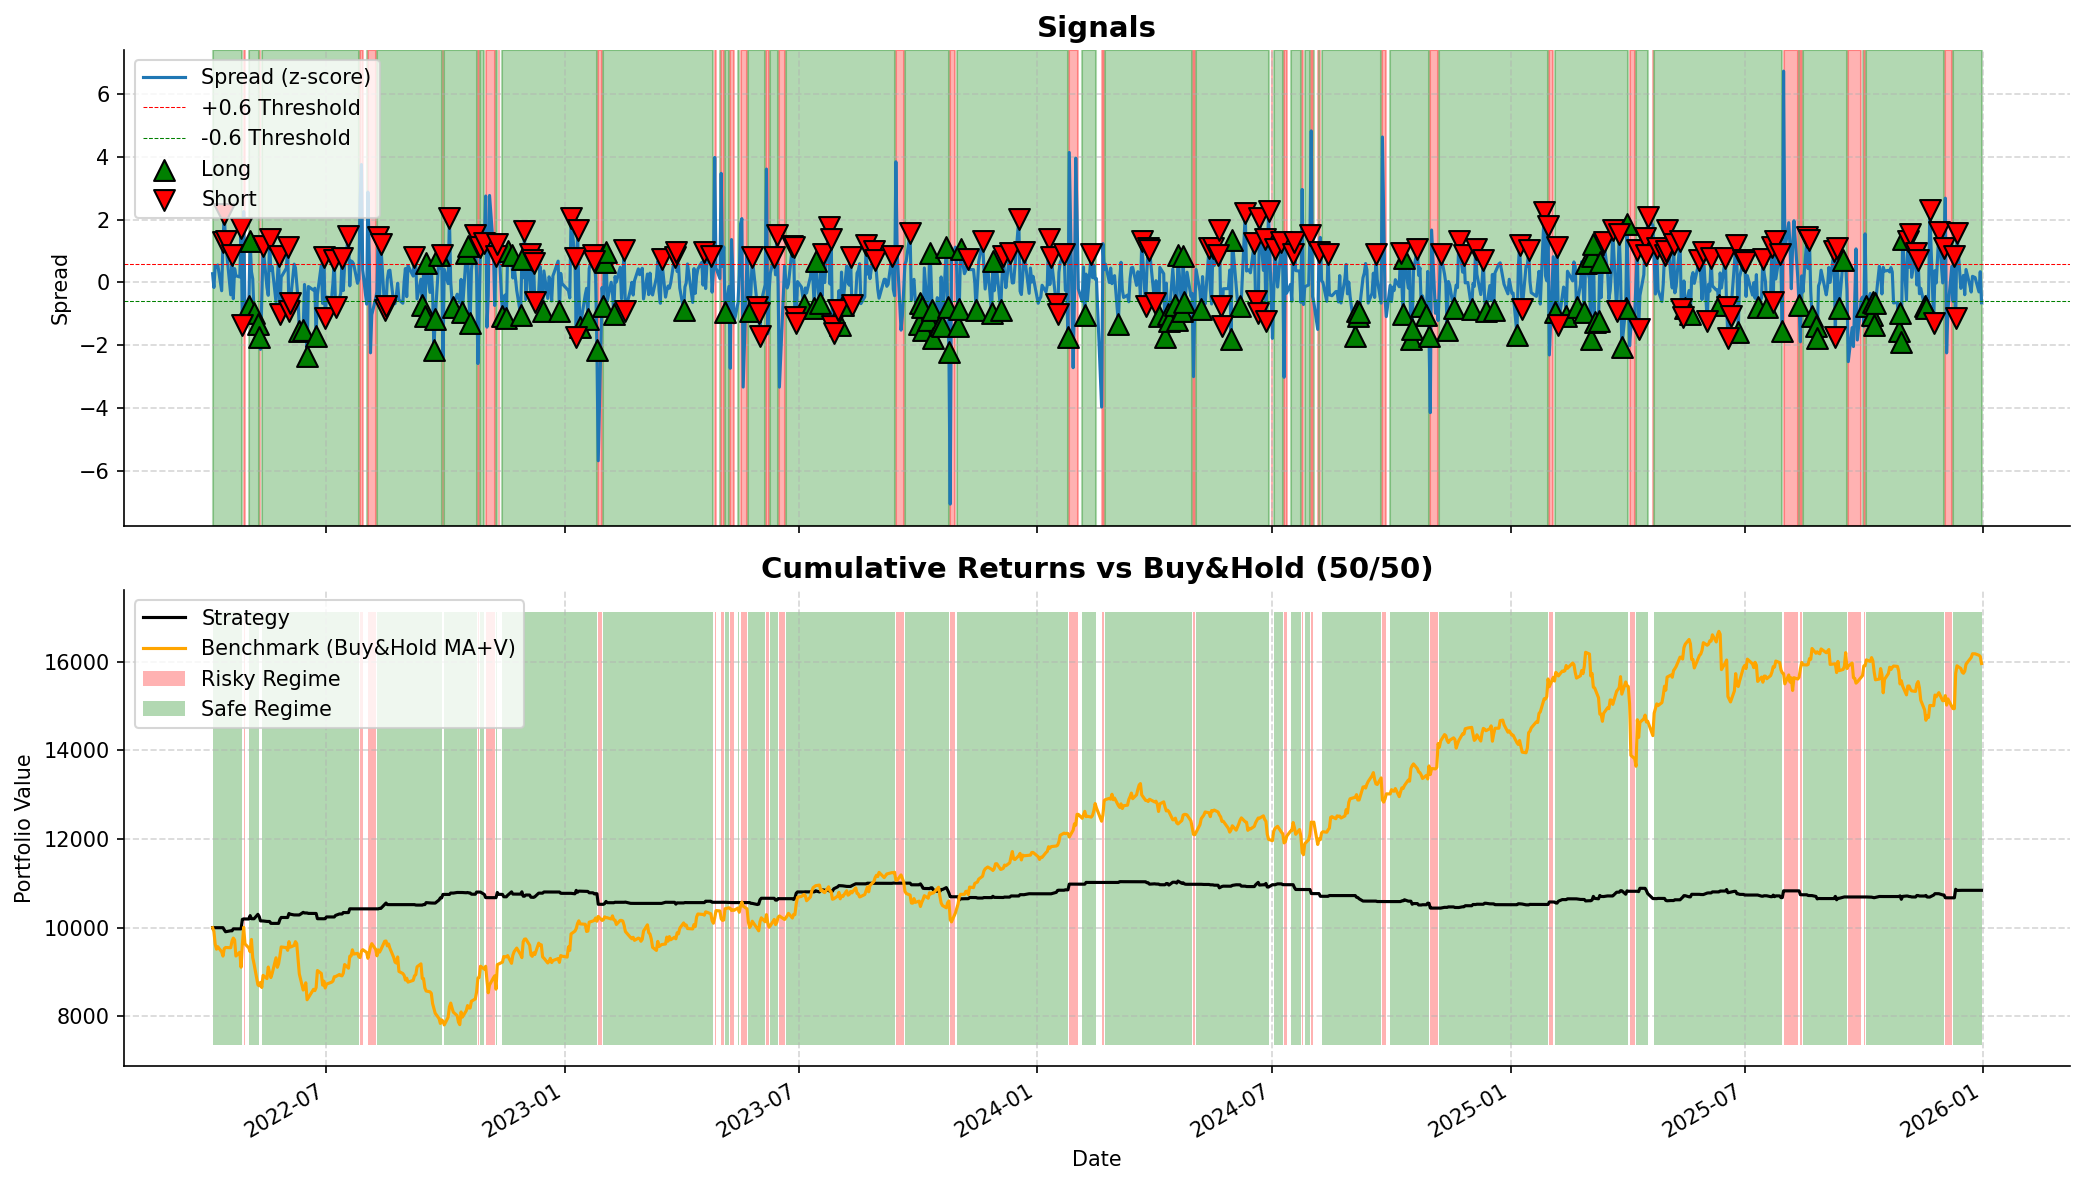

In [32]:
# 5. Backtest 
initial_capital = 10000.0
cost_bps = 0.0001  # 1 bps = 0.01% per lato
y_col, x_col = tickers[0], tickers[1]

df['r_y'] = df[y_col].pct_change().fillna(0.0)
df['r_x'] = df[x_col].pct_change().fillna(0.0)

beta_lag = df['beta_t'].shift(1).ffill()
beta_lag = beta_lag.clip(-10,10)
pos = df['position']              
gross = 1.0 + beta_lag.abs()       

# Pesi di portafoglio (long spread = +Y, -βX)
w_y =  pos / gross                  # +1/gross se long-spread, -1/gross se short-spread
w_x = -pos * beta_lag / gross       # -β/gross se long-spread, +β/gross se short-spread


ret_gross = w_y * df['r_y'] + w_x * df['r_x']
w_y_prev = w_y.shift(1).fillna(0.0)
w_x_prev = w_x.shift(1).fillna(0.0)
turnover = (w_y - w_y_prev).abs() + (w_x - w_x_prev).abs()
cost = cost_bps * turnover
df['strategy_ret'] = (ret_gross - cost).replace([np.inf, -np.inf], 0.0).fillna(0.0)


# Benchmark 50/50 semplice
bench_ret = (df['r_y'] + df['r_x']) / 2.0
df['benchmark_ret'] = bench_ret.fillna(0.0)

df['strategy_cum']  = (1.0 + df['strategy_ret']).cumprod() * initial_capital
df['benchmark_cum'] = (1.0 + df['benchmark_ret']).cumprod() * initial_capital

df['strategy_equity']   = df['strategy_cum']          # alias leggibile
df['benchmark_equity']  = df['benchmark_cum']

# PnL per periodo (in valuta): differenza di equity
df['strategy_pnl']   = df['strategy_equity'].diff().fillna(0.0)
df['benchmark_pnl']  = df['benchmark_equity'].diff().fillna(0.0)


# 6. Performance
def metrics(
    df: pd.DataFrame,
    ret_col: str = "strategy_ret",
    initial_capital: float = 100.0,
    rf_per_period: float = 0.00,   # risk-free per periodo 
    sortino_target: float = 0.0,  # target per-period per il Sortino (0 = MAR nullo)
    periods_per_year: int | None = None
):

    r = pd.Series(df[ret_col]).dropna().astype(float)
    if len(r) == 0:
        return {k: np.nan for k in ["CAGR","Ann. Volatility","Sharpe","Sortino","Max Drawdown","Calmar"]}

    # deduci periodi/anno se non specificato (fallback 252)
    if periods_per_year is None:
        periods_per_year = 252
        if isinstance(df.index, pd.DatetimeIndex) and len(df.index) > 1:
            periods_per_year = 252  # semplice e robusto per daily trading days

    # equity ricostruita dai rendimenti
    equity = (1 + r).cumprod() * float(initial_capital)

    # CAGR
    n_years = len(r) / periods_per_year
    cagr = (equity.iloc[-1] / float(initial_capital)) ** (1 / n_years) - 1 if n_years > 0 else np.nan

    # Volatilità annualizzata (std campionaria)
    ann_vol = r.std(ddof=1) * np.sqrt(periods_per_year)

    # Sharpe (unitless) su excess returns
    rex = r - rf_per_period
    sharpe = (rex.mean() * periods_per_year) / (rex.std(ddof=1) * np.sqrt(periods_per_year)) if rex.std(ddof=0) > 0 else np.nan

    # Sortino (unitless) con downside deviation vs target
    downside = r[r < sortino_target] - sortino_target
    downside_dev = downside.std(ddof=1) * np.sqrt(periods_per_year) if len(downside) > 1 else np.nan
    sortino = ((r.mean() - sortino_target) * periods_per_year) / downside_dev if (isinstance(downside_dev, float) and downside_dev > 0) else np.nan

    # Max Drawdown e Calmar
    roll_max = equity.cummax()
    drawdown = equity / roll_max - 1.0
    max_dd = float(drawdown.min())
    calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan

    # Curtosi
    kurt = r.kurtosis()

    return {
        "CAGR": cagr,
        "Ann. Volatility": ann_vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max Drawdown": max_dd,
        "Calmar": calmar,
        "Kurtosis": kurt
    }


m = metrics(df, ret_col="strategy_ret", initial_capital=100, rf_per_period=0.0)
for k, v in m.items():
    if k in {"CAGR","Ann. Volatility","Max Drawdown"} and pd.notna(v):
        print(f"{k}: {v:.2%}")
    elif k in {"Sharpe","Sortino","Calmar"} and pd.notna(v):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v}")


# ==============
# 6. PLOT

# Parametri
entry_thresh = 0.6  # !!!

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(14, 8), sharex=True)

x = df.index
in_regime = df['regime'] == 1  # ROSSO (high var)
out_regime = df['regime'] == 0 # VERDE (low var)

# --- Subplot 1: Spread con segnali e regimi ---
ymin1, ymax1 = df['z_kf'].min(), df['z_kf'].max()

# usa l’intero pannello in coordinate [0,1] sull’asse Y
ax1.fill_between(x, 0, 1, where=in_regime,  color='red',   alpha=0.3, transform=ax1.get_xaxis_transform())
ax1.fill_between(x, 0, 1, where=out_regime, color='green', alpha=0.3, transform=ax1.get_xaxis_transform())

ax1.plot(x, df['z_kf'], linewidth=1.5, label='Spread (z-score)')

ax1.axhline(entry_thresh, linestyle='--', linewidth=0.5, color='red',   label=f'+{entry_thresh} Threshold')
ax1.axhline(-entry_thresh, linestyle='--', linewidth=0.5, color='green', label=f'{-entry_thresh} Threshold')

long_idx  = df.index[df['signal'] ==  1]
short_idx = df.index[df['signal'] == -1]

ax1.scatter(long_idx,
            df.loc[long_idx, 'z_kf'],
            marker='^', s=100, edgecolor='k', facecolor='green', label='Long',  zorder=5)
ax1.scatter(short_idx,
            df.loc[short_idx, 'z_kf'],
            marker='v', s=100, edgecolor='k', facecolor='red',   label='Short', zorder=5)

ax1.set_title('Signals', fontsize=14)
ax1.set_ylabel('Spread')
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.5)


# --- Subplot 2: Cumulative Returns con regimi ---
ax2.plot(x, df['strategy_cum'],  label="Strategy", color='black')
ax2.plot(x, df['benchmark_cum'], label="Benchmark (Buy&Hold MA+V)", color='orange')

ymin2, ymax2 = ax2.get_ylim()

ax2.fill_between(x, ymin2, ymax2, where=in_regime,  # regime==1 (alta varianza)
                 facecolor='red',  alpha=0.3, label="Risky Regime")
ax2.fill_between(x, ymin2, ymax2, where=out_regime, # regime==0 (bassa varianza)
                 facecolor='green', alpha=0.3, label="Safe Regime")

ax2.set_title('Cumulative Returns vs Buy&Hold (50/50)', fontsize=14)
ax2.set_ylabel('Portfolio Value')
ax2.set_xlabel('Date')
ax2.legend(loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.5)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()



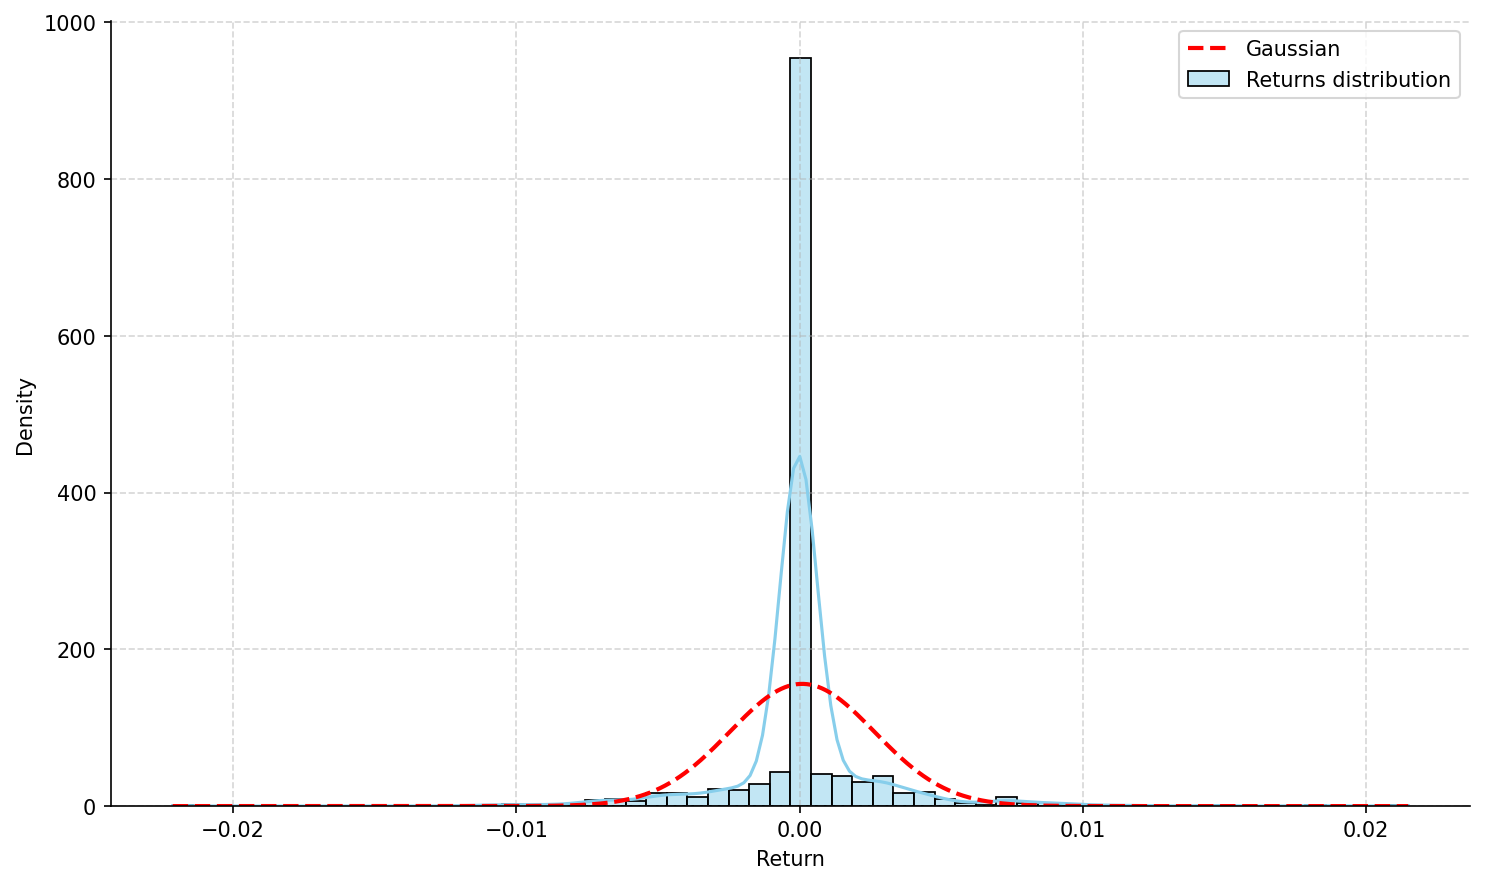

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


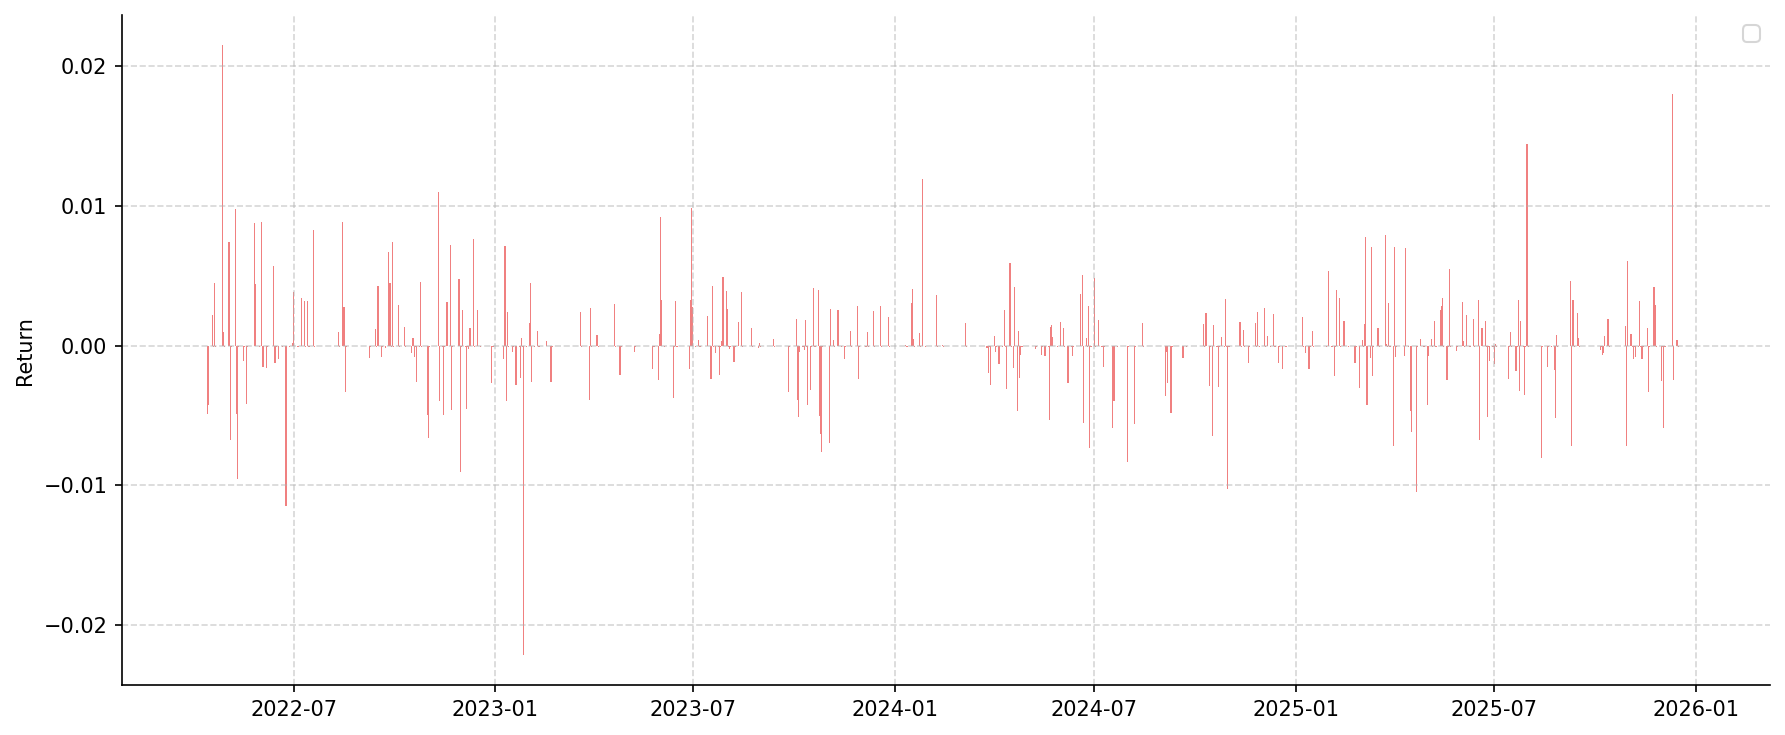

In [39]:
from scipy.stats import norm


r = df['strategy_ret'].dropna()
mu, sigma = r.mean(), r.std()

# === 1) Distribuzione dei rendimenti ===
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(r, bins=60, kde=True, color='skyblue', stat='density', label='Returns distribution', ax=ax)

x = np.linspace(r.min(), r.max(), 1000)
ax.plot(x, norm.pdf(x, mu, sigma), 'r--', linewidth=2, label='Gaussian')

ax.set_xlabel('Return')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# === 2) Rendimenti per periodo (time series) ===
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(r.index, r, width=1.0, color='lightcoral')
ax.set_ylabel('Return')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

In [40]:
df

Ticker,MA,V,alpha_t,beta_t,spread_kf,rolling_mean,rolling_std,z_kf,regime,signal,...,r_y,r_x,strategy_ret,benchmark_ret,strategy_cum,benchmark_cum,strategy_equity,benchmark_equity,strategy_pnl,benchmark_pnl
Date,,,,,,,,,,,,,,,,,,,,,
2022-04-04,358.348206,220.882843,1.827105,1.613830,0.053815,-0.030636,0.302470,0.279204,0,0,...,0.000000,0.000000,0.0,0.000000,10000.000000,10000.000000,10000.000000,10000.000000,0.0,0.000000
2022-04-05,354.842041,219.282532,1.641882,1.611044,-0.073719,-0.025829,0.301465,-0.158858,0,0,...,-0.009784,-0.007245,0.0,-0.008515,10000.000000,9914.853463,10000.000000,9914.853463,0.0,-85.146537
2022-04-06,345.300018,212.415726,2.533941,1.613059,0.126946,-0.033232,0.296989,0.539341,0,0,...,-0.026891,-0.031315,0.0,-0.029103,10000.000000,9626.302564,10000.000000,9626.302564,0.0,-288.550899
2022-04-07,341.867126,209.641815,2.969536,1.616052,0.105509,-0.036055,0.294599,0.480533,0,0,...,-0.009942,-0.013059,0.0,-0.011500,10000.000000,9515.596999,10000.000000,9515.596999,0.0,-110.705565
2022-04-08,344.527405,210.446838,3.091878,1.621805,0.131752,-0.032060,0.294871,0.555540,0,0,...,0.007782,0.003840,0.0,0.005811,10000.000000,9570.890269,10000.000000,9570.890269,0.0,55.293271
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-24,578.580933,354.409180,60.404647,1.462032,0.018601,-0.007947,0.135465,0.195982,0,0,...,0.005379,0.004980,0.0,0.005180,10842.733367,16177.538166,10842.733367,16177.538166,0.0,83.361663
2025-12-26,578.730652,354.269470,60.423882,1.462989,0.014441,-0.006794,0.135390,0.156843,0,0,...,0.000259,-0.000394,0.0,-0.000068,10842.733367,16176.442670,10842.733367,16176.442670,0.0,-1.095495
2025-12-29,577.033264,353.880249,60.350725,1.460171,-0.043244,-0.003401,0.133277,-0.298944,0,0,...,-0.002933,-0.001099,0.0,-0.002016,10842.733367,16143.834133,10842.733367,16143.834133,0.0,-32.608537


In [41]:
import vectorbt as vbt

# Prezzi
y_ticker, x_ticker = tickers[:2]                
prices = df[[y_ticker, x_ticker]].astype(float)

# Pesi
beta_lag = df['beta_t'].shift(1).ffill().clip(-10, 10)
pos = df['signal'].fillna(0.0) # vbt fa già lo shift(1) --> usare df[signal]
gross = 1.0 + beta_lag.abs()

w_y =  pos / gross
w_x = -pos * beta_lag / gross

weights = pd.DataFrame({
    y_ticker: w_y,
    x_ticker: w_x
}, index=prices.index).fillna(0.0)


# BT
pf = vbt.Portfolio.from_orders(
    close=prices,
    size=weights,
    size_type='targetpercent',
    init_cash=10_000,
    fees=0.0001,
    cash_sharing=True,
    freq='1D'
)

print(pf.stats())
pf.plot().show()


Start                            2022-04-04 00:00:00
End                              2025-12-31 00:00:00
Period                             940 days 00:00:00
Start Value                                  10000.0
End Value                               10846.317781
Total Return [%]                            8.463178
Benchmark Return [%]                       58.759772
Max Gross Exposure [%]                    140.482708
Total Fees Paid                           401.684575
Max Drawdown [%]                            5.554135
Max Drawdown Duration              426 days 00:00:00
Total Trades                                     491
Total Closed Trades                              491
Total Open Trades                                  0
Open Trade PnL                                   0.0
Win Rate [%]                               52.749491
Best Trade [%]                              9.705514
Worst Trade [%]                           -10.110807
Avg Winning Trade [%]                       1.

/opt/anaconda3/lib/python3.11/site-packages/vectorbt/generic/plots_builder.py:339: UserWarning: Subplot 'orders' does not support grouped data
  warnings.warn(warning_message)
/opt/anaconda3/lib/python3.11/site-packages/vectorbt/generic/plots_builder.py:339: UserWarning: Subplot 'trade_pnl' does not support grouped data
  warnings.warn(warning_message)


In [44]:
# Borroni and Deflated Sharpe Ratio

N_trials = 60
rets = pf.returns().dropna().values

def sharpe_per_period(returns):
    """Sharpe ratio non annualizzato (per-period)."""
    r = np.asarray(returns, dtype=float)
    r = r[np.isfinite(r)]
    if r.size < 2:
        return np.nan
    mu = r.mean()
    sd = r.std(ddof=1)
    return 0.0 if sd == 0 else mu / sd


def sharpe_pvalue_two_sided(returns, sr0=0.0):
    """
    p-value (two-sided) per test H0: SR <= sr0.
    Usa approssimazione normale del t-statistic.
    """
    r = np.asarray(returns, dtype=float)
    r = r[np.isfinite(r)]
    T = r.size
    if T < 2:
        return np.nan
    
    sr_hat = sharpe_per_period(r)
    z = (sr_hat - sr0) * np.sqrt(T - 1)
    return 2.0 * (1.0 - norm.cdf(abs(z)))


def bonferroni_alpha(pvals, alpha=0.05):
    p = np.asarray(pvals, dtype=float)
    mask = np.isfinite(p)
    m = int(mask.sum())
    if m == 0:
        return np.nan, np.full_like(p, False, dtype=bool)

    alpha_bonf = alpha / m
    significant = np.zeros_like(p, dtype=bool)
    significant[mask] = p[mask] < alpha_bonf
    return alpha_bonf, significant



def deflated_sharpe_ratio(returns, N_trials, sr_trials=None):
    """
    Deflated Sharpe Ratio.
    
    Args:
        returns: returns per-period della strategia selezionata
        N_trials: numero di strategie testate
        sr_trials: Sharpe di tutti i trial (opzionale)
    
    Returns:
        Probabilità che SR sia statisticamente significativo dopo data snooping
    """
    r = np.asarray(returns, dtype=float)
    r = r[np.isfinite(r)]
    T = r.size
    if T < 2 or N_trials < 1:
        return np.nan

    sr_star = sharpe_per_period(r)

    # Momenti campionari
    g3 = skew(r, bias=False) if T >= 3 else 0.0
    g4 = kurtosis(r, fisher=False, bias=False) if T >= 4 else 3.0

    # Varianza dello Sharpe ratio
    if sr_trials is not None:
        srt = np.asarray(sr_trials, dtype=float)
        srt = srt[np.isfinite(srt)]
        V_sr = np.var(srt, ddof=1) if srt.size >= 2 else 1.0 / (T - 1)
    else:
        V_sr = 1.0 / (T - 1)

    # Soglia SR0 = expected max Sharpe di N_trials sotto H0
    gamma = 0.5772156649015329  # Euler-Mascheroni constant
    z1 = norm.ppf(1.0 - 1.0 / N_trials)
    z2 = norm.ppf(1.0 - 1.0 / (N_trials * np.e))
    sr0 = np.sqrt(V_sr) * ((1.0 - gamma) * z1 + gamma * z2)

    # DSR
    denom = np.sqrt(1.0 - g3 * sr0 + ((g4 - 1.0) / 4.0) * (sr0 ** 2))
    z = ((sr_star - sr0) * np.sqrt(T - 1.0)) / denom
    
    return float(norm.cdf(z))


sr_hat = sharpe_per_period(rets)
pval = sharpe_pvalue_two_sided(rets, sr0=0.0)
if np.isfinite(pval) and N_trials >= 1:
    alpha_bonf = 0.05 / N_trials
    pval_bonf = min(pval * N_trials, 1.0)
    significant_bonf = (pval < alpha_bonf)  # equivalente a pval_bonf < alpha
else:
    alpha_bonf = np.nan
    pval_bonf = np.nan
    significant_bonf = False


dsr = deflated_sharpe_ratio(r, N_trials=N_trials)

In [47]:
print('p-value Bonferroni: ', pval_bonf)
print('deflated Sharpe ratio: ', dsr)

p-value Bonferroni:  1.0
deflated Sharpe ratio:  0.0996057237983729
